# Taller 5 Modelos de Clasificación - Predicción de Envíos en E-Commerce Carlos Fernando Gonzalez Sarmiento
 
En este notebook encontrarán la estructura general para desarrollar el modelo predictivo de retrasos en los envíos. Sigan las instrucciones de cada sección y completen el código correspondiente.

In [1]:
# Paso 0: Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# TIP: Asegúrense de importar aquí los tres clasificadores de scikit-learn que elijan probar,
# junto con las métricas de evaluación (accuracy_score, confusion_matrix, etc.)

## 1. Carga de Datos y Análisis Exploratorio Inicial

Los datos para realizar el ejercicio se encuentran aqui: [E-Commerce Shipping Data](https://www.kaggle.com/datasets/prachi13/customer-analytics)

In [2]:
# Paso 1: Usa pandas para cargar el dataset descargado de Kaggle

df_envios = pd.read_csv(r"C:\Users\piki_\Downloads\Train.csv")
df_envios.head()

# TIP: Exploren las primeras filas con .head(), verifiquen los tipos de datos con .info()
# y revisen si existen valores nulos antes de avanzar.


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
df_envios.shape # 12 columnas

(10999, 12)

In [4]:
df_envios.info() #información de mis variables

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [5]:
df_envios.isna().sum() # sin nulos

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [6]:
df_envios.duplicated().sum() #Sin valores duplicados

0

In [7]:
df_envios.describe() # descriptivas de valores numericos

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [8]:
df_envios.describe(include="object") #Describe que encontre para variables tipo object

,Warehouse_block,Mode_of_Shipment,Product_importance,Gender
count,10999,10999,10999,10999
unique,5,3,3,2
top,F,Ship,low,F
freq,3666,7462,5297,5545


In [9]:
df_envios["Reached.on.Time_Y.N"].value_counts() #Mi variable de entregados a tiempo, claramente mi variable objetivo

1    6563
0    4436
Name: Reached.on.Time_Y.N, dtype: int64

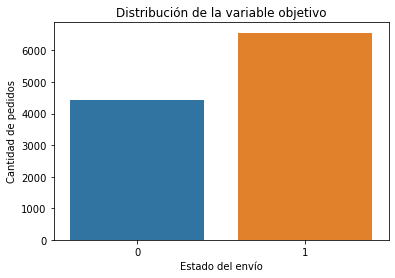

In [10]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_envios,
    x="Reached.on.Time_Y.N"
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Estado del envío")
plt.ylabel("Cantidad de pedidos")

plt.show()
# Veamos la distribución de mi variable objetivo

La gráfica permite observar la cantidad de pedidos pertenecientes a cada clase, esta revisión es importante para determinar si la variable objetivo se encuentra
balanceada y para decidir qué métricas deben tener mayor importancia durante la
evaluación de los modelos.

Sin embargo vemos mayoría de entregas no se han hecho a tiempo

## 2. Preprocesamiento de Datos e Ingeniería de Características
En esta sección deben transformar las variables categóricas en formatos numéricos aptos para los modelos.

In [11]:
#Paso 2: Identificación y transformación de variables categóricas

df_modelo = df_envios.copy()
df_modelo = df_modelo.drop("ID", axis=1) # El ID como su nombre lo dice solo es un ID de registros

df_modelo.head()

# TIP 1 (Encoding Ordinal): Analicen la columna 'Product_importance'. ¿Tiene un orden lógico?
# Apliquen una estrategia que conserve esa jerarquía (ej. low=1, medium=2, high=3).

# TIP 2 (One-Hot Encoding): Analicen las columnas 'Mode_of_Shipment' y 'Warehouse_block'.
# Al no tener un orden lógico, utilicen One-Hot Encoding (pd.get_dummies o OneHotEncoder).

# TIP 3: Recuerden definir claramente su matriz de características (X) y el vector objetivo (y).
# El target para este problema es la columna 'Reached.on.Time_Y.N'.

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1


In [12]:
orden_importancia = { # si tiene un orden logico
    "low": 1,
    "medium": 2,
    "high": 3
}

df_modelo["Product_importance"] = (
    df_modelo["Product_importance"]
    .str.lower()
    .map(orden_importancia)
)
df_modelo["Product_importance"].value_counts().sort_index()

1    5297
2    4754
3     948
Name: Product_importance, dtype: int64

##### Codificación de la importancia del producto

La variable `Product_importance` tiene un orden natural entre sus categorías.
Por esta razón, se utilizó una codificación ordinal, asignando 1 a importancia
baja, 2 a importancia media y 3 a importancia alta.

In [13]:
df_modelo.select_dtypes(include="object").columns
#Me quedan estas variables tipo object

Index(['Warehouse_block', 'Mode_of_Shipment', 'Gender'], dtype='object')

In [14]:
columnas_nominales = [
    "Warehouse_block",
    "Mode_of_Shipment",
    "Gender"
]

df_modelo = pd.get_dummies(
    df_modelo,
    columns=columnas_nominales,
    drop_first=True,
    dtype=int
)

df_modelo.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Gender_M
0,4,2,177,3,1,44,1233,1,0,0,1,0,0,0,0
1,4,5,216,2,1,59,3088,1,0,0,0,1,0,0,1
2,2,2,183,4,1,48,3374,1,0,0,0,0,0,0,1
3,3,3,176,4,2,10,1177,1,1,0,0,0,0,0,1
4,2,2,184,3,2,46,2484,1,0,1,0,0,0,0,0


Además de las variables `Mode_of_Shipment` y `Warehouse_block`, se incluyó
la variable `Gender` en el proceso de One-Hot Encoding, ya que también es una
variable categórica sin un orden lógico.

Aunque el género del cliente no presenta una relación logística directa con
el tiempo de entrega, se conserva inicialmente para evaluar si aporta
información al modelo. En una aplicación real, su uso debería revisarse
cuidadosamente para evitar posibles sesgos.

In [15]:
# X contiene las variables utilizadas para realizar la predicción
X = df_modelo.drop(
    "Reached.on.Time_Y.N",
    axis=1
)

# y contiene la variable que queremos predecir (objetivo)
y = df_modelo["Reached.on.Time_Y.N"]

In [16]:
X.shape

(10999, 14)

In [17]:
y.shape

(10999,)

In [18]:
X.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Gender_M
0,4,2,177,3,1,44,1233,0,0,1,0,0,0,0
1,4,5,216,2,1,59,3088,0,0,0,1,0,0,1
2,2,2,183,4,1,48,3374,0,0,0,0,0,0,1
3,3,3,176,4,2,10,1177,1,0,0,0,0,0,1
4,2,2,184,3,2,46,2484,0,1,0,0,0,0,0


In [19]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Reached.on.Time_Y.N, dtype: int64

## 3. División del Dataset
Separación de los datos en conjuntos de entrenamiento y prueba.

In [20]:
# Paso 3: Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# TIP: Utilicen train_test_split de sklearn. Configuren un test_size adecuado (ej. 15% o 20%)
# y un random_state fijo para que sus resultados sean replicables.

X_train: (8799, 14)
X_test: (2200, 14)
y_train: (8799,)
y_test: (2200,)


In [21]:
# Hora de escalar las variables numericas
columnas_a_escalar = [
    "Customer_care_calls",
    "Customer_rating",
    "Cost_of_the_Product",
    "Prior_purchases",
    "Product_importance",
    "Discount_offered",
    "Weight_in_gms"
]
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()

X_train_scaled[columnas_a_escalar] = scaler.fit_transform(
    X_train[columnas_a_escalar]
)

X_test_scaled[columnas_a_escalar] = scaler.transform(
    X_test[columnas_a_escalar]
)

In [22]:
X_train_scaled.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Gender_M
7920,-0.043121,-1.415468,1.056631,-1.032208,0.609537,-0.270466,0.322365,0,0,1,0,1,0,0
1529,-0.921405,0.001852,-1.003783,-1.032208,-0.946852,0.782420,-1.206929,0,0,0,1,0,1,0
10521,-0.921405,-0.706808,0.224140,-1.032208,0.609537,-0.270466,0.510849,1,0,0,0,0,1,1
9558,-0.921405,1.419173,-1.107845,0.272734,0.609537,-0.704008,0.617330,0,0,1,0,0,1,0
968,-1.799688,1.419173,1.285566,-1.032208,-0.946852,0.658551,0.004144,0,0,0,0,0,0,1


## 4. Entrenamiento de Modelos
 
Deben seleccionar, entrenar y evaluar tres algoritmos de clasificación distintos (por ejemplo: Regresión Logística, Árboles de Decisión, Random Forest, KNN, etc.).

##### Se entrenarán tres modelos de clasificación: Regresión Logística, K-Nearest Neighbors (KNN) y Random Forest. Cada modelo será evaluado utilizando accuracy, precision, recall, F1-score y una matriz de confusión.

In [23]:
## Paso 4: Entrenamiento y evaluación de modelos

# Modelo 1: Instanciar, entrenar con datos de train y predecir con datos de test

modelo_logistico = LogisticRegression(
    random_state=42,
    max_iter=1000
)

modelo_logistico.fit(
    X_train_scaled,
    y_train
)

y_pred_logistico = modelo_logistico.predict(
    X_test_scaled
)

accuracy_logistico = accuracy_score(
    y_test,
    y_pred_logistico
)

precision_logistico = precision_score(
    y_test,
    y_pred_logistico,
    zero_division=0
)

recall_logistico = recall_score(
    y_test,
    y_pred_logistico,
    zero_division=0
)

f1_logistico = f1_score(
    y_test,
    y_pred_logistico,
    zero_division=0
)

#Mis metricas, mas adelante se dara la conclusion si son buenas o malas o demás
print("Regresión Logística")
print("Accuracy:", round(accuracy_logistico, 4))
print("Precision:", round(precision_logistico, 4))
print("Recall:", round(recall_logistico, 4))
print("F1-score:", round(f1_logistico, 4))

Regresión Logística
Accuracy: 0.6405
Precision: 0.7091
Recall: 0.674
F1-score: 0.6911


In [24]:
print(
    classification_report(
        y_test,
        y_pred_logistico,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.55      0.59      0.57       887
           1       0.71      0.67      0.69      1313

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.65      0.64      0.64      2200



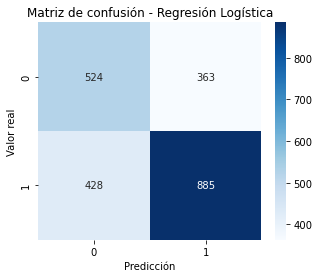

In [25]:
matriz_logistico = confusion_matrix(
    y_test,
    y_pred_logistico
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    matriz_logistico,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [26]:
# Modelo 2: Instanciar, entrenar con datos de train y predecir con datos de test

modelo_knn = KNeighborsClassifier(
    n_neighbors=5
)

modelo_knn.fit(
    X_train_scaled,
    y_train
)

y_pred_knn = modelo_knn.predict(
    X_test_scaled
)

accuracy_knn = accuracy_score(
    y_test,
    y_pred_knn
)

precision_knn = precision_score(
    y_test,
    y_pred_knn,
    zero_division=0
)

recall_knn = recall_score(
    y_test,
    y_pred_knn,
    zero_division=0
)

f1_knn = f1_score(
    y_test,
    y_pred_knn,
    zero_division=0
)

print("K-Nearest Neighbors")
print("Accuracy:", round(accuracy_knn, 4))
print("Precision:", round(precision_knn, 4))
print("Recall:", round(recall_knn, 4))
print("F1-score:", round(f1_knn, 4))


K-Nearest Neighbors
Accuracy: 0.6386
Precision: 0.7133
Recall: 0.6596
F1-score: 0.6854


In [27]:
print(
    classification_report(
        y_test,
        y_pred_knn,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.55      0.61      0.58       887
           1       0.71      0.66      0.69      1313

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.65      0.64      0.64      2200



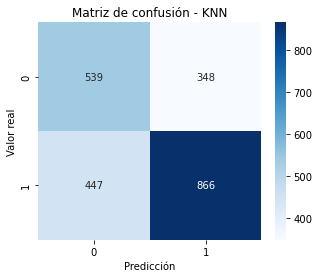

In [28]:
matriz_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    matriz_knn,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de confusión - KNN")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [29]:
# Modelo 3: Instanciar, entrenar con datos de train y predecir con datos de test
# Modelo 3: Random Forest

# Random Forest no necesita que las variables estén escaladas

modelo_random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_random_forest.fit(
    X_train,
    y_train
)

y_pred_random_forest = modelo_random_forest.predict(
    X_test
)

accuracy_random_forest = accuracy_score(
    y_test,
    y_pred_random_forest
)

precision_random_forest = precision_score(
    y_test,
    y_pred_random_forest,
    zero_division=0
)

recall_random_forest = recall_score(
    y_test,
    y_pred_random_forest,
    zero_division=0
)

f1_random_forest = f1_score(
    y_test,
    y_pred_random_forest,
    zero_division=0
)

print("Random Forest")
print("Accuracy:", round(accuracy_random_forest, 4))
print("Precision:", round(precision_random_forest, 4))
print("Recall:", round(recall_random_forest, 4))
print("F1-score:", round(f1_random_forest, 4))

Random Forest
Accuracy: 0.6586
Precision: 0.7641
Recall: 0.6192
F1-score: 0.6841


In [30]:
print(
    classification_report(
        y_test,
        y_pred_random_forest,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.56      0.72      0.63       887
           1       0.76      0.62      0.68      1313

    accuracy                           0.66      2200
   macro avg       0.66      0.67      0.66      2200
weighted avg       0.68      0.66      0.66      2200



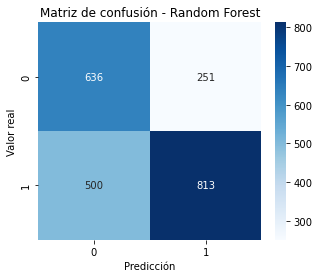

In [31]:
matriz_random_forest = confusion_matrix(
    y_test,
    y_pred_random_forest
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    matriz_random_forest,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## 5. Evaluación y Comparación de Resultados
Generen las métricas y las gráficas solicitadas para contrastar el rendimiento de los tres modelos.

In [32]:
# Paso 5: Cálculo de métricas para cada modelo por medio de accuracy_score, confusion_matrix, classification_report, etc.
# TIP: Almacenen los resultados de Accuracy en un diccionario o DataFrame para facilitar la graficación.

## 5. Evaluación y comparación de resultados

Para comparar el rendimiento de los tres modelos, se reúnen las métricas de
Accuracy, Precision, Recall y F1-score en una sola tabla.

La comparación permite identificar cuál modelo tiene un mejor comportamiento
general y cuál logra un mejor equilibrio entre las predicciones correctas y
la identificación de la clase positiva.

In [33]:
# Tabla comparativa de métricas

resultados_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "KNN",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistico,
        accuracy_knn,
        accuracy_random_forest
    ],
    "Precision": [
        precision_logistico,
        precision_knn,
        precision_random_forest
    ],
    "Recall": [
        recall_logistico,
        recall_knn,
        recall_random_forest
    ],
    "F1-score": [
        f1_logistico,
        f1_knn,
        f1_random_forest
    ]
})

resultados_modelos = resultados_modelos.round(4)

resultados_modelos

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.6405,0.7091,0.6740,0.6911
1,KNN,0.6386,0.7133,0.6596,0.6854
2,Random Forest,0.6586,0.7641,0.6192,0.6841


In [34]:
resultados_modelos.sort_values(
    by="F1-score",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.6405,0.7091,0.6740,0.6911
1,KNN,0.6386,0.7133,0.6596,0.6854
2,Random Forest,0.6586,0.7641,0.6192,0.6841


Como se aprendió en clase el "F1-score" representa un equilibrio entre Precision y Recall, por lo que es útil cuando no queremos evaluar el modelo solamente por la cantidad total de aciertos.

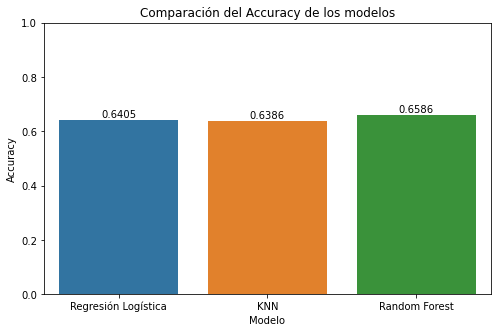

In [35]:
# Paso 6: Gráfica comparativa de Accuracy
# TIP: Utilicen un gráfico de barras (sns.barplot o plt.bar) donde el eje X sean los modelos
# y el eje Y sea el valor de Accuracy obtenido.

plt.figure(figsize=(8, 5))

grafica_accuracy = sns.barplot(
    data=resultados_modelos,
    x="Modelo",
    y="Accuracy"
)

plt.title("Comparación del Accuracy de los modelos")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, valor in enumerate(resultados_modelos["Accuracy"]):
    plt.text(
        i,
        valor + 0.01,
        round(valor, 4),
        ha="center"
    )

plt.show()

#Esta es de solo accuracy

In [36]:
resultados_grafica = resultados_modelos.melt(
    id_vars="Modelo",
    var_name="Métrica",
    value_name="Valor"
)

resultados_grafica

,Modelo,Métrica,Valor
0,Regresión Logística,Accuracy,0.6405
1,KNN,Accuracy,0.6386
2,Random Forest,Accuracy,0.6586
3,Regresión Logística,Precision,0.7091
4,KNN,Precision,0.7133
5,Random Forest,Precision,0.7641
6,Regresión Logística,Recall,0.6740
7,KNN,Recall,0.6596
8,Random Forest,Recall,0.6192
9,Regresión Logística,F1-score,0.6911


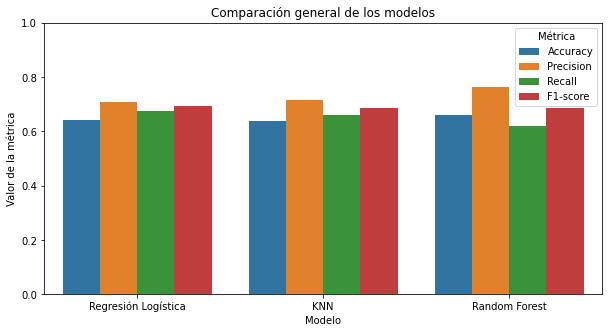

In [37]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=resultados_grafica,
    x="Modelo",
    y="Valor",
    hue="Métrica"
)

plt.title("Comparación general de los modelos")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.legend(title="Métrica")

plt.show()

#Esta es de todas las metricas para cada modelo

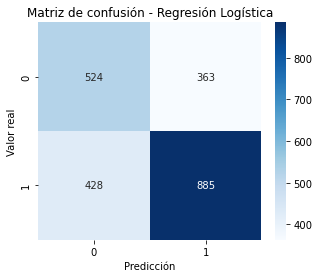

In [38]:
# Paso 7: Matrices de Confusión
# TIP: Generen y visualicen la matriz de confusión para cada uno de los tres modelos utilizando sns.heatmap.
# Esto les permitirá analizar visualmente los falsos positivos y falsos negativos de cada algoritmo.

# Esto ya lo había realizado arriba pero lo pego nuevamente por si acaso

# Matriz de confusión - Regresión Logística
matriz_logistico = confusion_matrix(y_test, y_pred_logistico)

plt.figure(figsize=(5, 4))
sns.heatmap(matriz_logistico, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

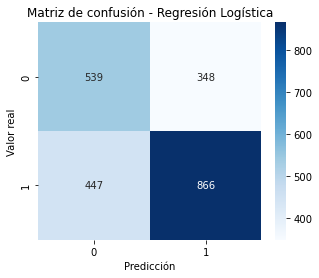

In [39]:
# Matriz de confusión - KNN
matriz_logistico = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(matriz_logistico, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

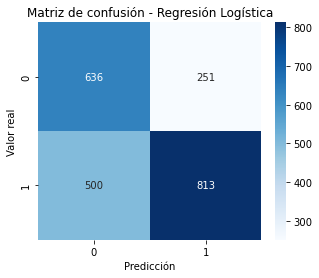

In [40]:
# Matriz de confusión - Random Forest
matriz_logistico = confusion_matrix(y_test, y_pred_random_forest)

plt.figure(figsize=(5, 4))
sns.heatmap(matriz_logistico, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## Conclusión

En este ejercicio se entrenaron y evaluaron tres modelos de clasificación: **Regresión Logística, KNN y Random Forest**. El objetivo fue predecir si un pedido se entregaría a tiempo o presentaría un retraso.

Al comparar los resultados, **Random Forest** obtuvo el Accuracy más alto, con un 65,86 %, lo que significa que fue el modelo con el mayor porcentaje general de predicciones correctas. También obtuvo la Precision más alta, con un 76,41 %, por lo que sus predicciones de pedidos retrasados fueron más precisas.

Sin embargo, **Random Forest** obtuvo el Recall más bajo, con un 61,92 %. Esto indica que tuvo mayores dificultades para identificar todos los pedidos que realmente presentaron un retraso, clasificando algunos de ellos como entregas realizadas a tiempo.

Por otra parte, la **Regresión Logística** obtuvo el Recall más alto, con un 67,40 %, y el mejor F1-score, con un 69,11 %. Aunque su Accuracy fue ligeramente menor que el de Random Forest, con un 64,05 %, presentó un mejor equilibrio entre la identificación de los pedidos entregados a tiempo y los pedidos retrasados.

**KNN** obtuvo resultados similares, pero no logró superar a los demás modelos en ninguna de las métricas analizadas. Su Accuracy fue del 63,86 % y su F1-score fue del 68,54 %.

Teniendo en cuenta los resultados, considero que la **Regresión Logística es el modelo más adecuado para este ejercicio**. Aunque Random Forest tuvo un mayor porcentaje general de aciertos, la Regresión Logística presentó el mejor F1-score y una mayor capacidad para detectar pedidos con retraso.

En conclusión, para seleccionar el mejor modelo no fue suficiente observar únicamente el Accuracy. También fue necesario analizar la Precision, el Recall, el F1-score y las matrices de confusión, con el fin de evaluar qué tan bien cada modelo diferencia entre los pedidos entregados a tiempo y aquellos que presentaron retrasos.

Sin embargo es claro que si fuera por temas de accuracy y precision el modelo escogido sería el **Random Forest**